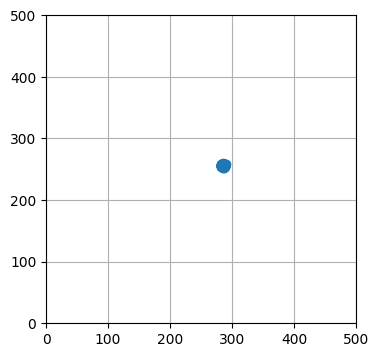

285.4692739507867 +/- 1.2226900679727357
256.37545731489587 +/- 1.0901155832539937


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def countsReturner(file_path):
    try:
        df = pd.read_csv(file_path, header=None, comment="#", on_bad_lines="skip")

        df.columns = ['EventID', 'TrackID', 'Particle', 'EnergyDeposited',
                    'LocalTime', 'Volume', 'Copynumber', 'Initial Energy',
                        'Origin Volume', 'ParentID', 'ProcessName']
        counts = []
        scintillationdf = df.loc[df['ProcessName'] == 'Scintillation']

        for i in scintillationdf['EventID'].unique():
            newdf = scintillationdf.loc[df['EventID'] == i]
            # print(newdf.groupby("Copynumber").size())
            # print(newdf.groupby("Copynumber").size().reset_index(name="PhotonCount").to_numpy())
            sipm_counts = newdf.groupby("Copynumber").size().reset_index(name="PhotonCount")
            # print(sipm_counts)
            try:             
                counts.append([i, sipm_counts.to_numpy().T])
            except:
                pass
    except:
        pass
        
    return counts

path = "/home/alex-herscovics/Downloads/output (2)/output"

files = os.listdir(path)

big_array = []

for file in files:
    address = path + '/' + file
    big_array.append(countsReturner(address))


spacing = 62.5

def process_data(array):
    coords = array[1][0]
    rows = coords % 10
    cols = coords // 10
    vals = array[1][1]
    x_mm = 31.25+cols * spacing
    y_mm = 31.25+rows * spacing

    # photon counts (your actual data)
    weights = vals  # replace with your photon counts array

    # centroid calculation
    x_rec = np.sum(weights * x_mm) / np.sum(weights)
    y_rec = np.sum(weights * y_mm) / np.sum(weights)

    return (x_rec,y_rec)

xrecs = []
yrecs = []
for i in range(len(big_array)):
    for j in range(len(big_array[i])):
        # print(big_array[i][j][1][0])
        x, y = process_data(big_array[i][j])
        xrecs.append(x)
        yrecs.append(y)
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
ax.scatter(xrecs,yrecs)
ax.set_xlim(0,500)
ax.set_ylim(0,500)
ax.grid()

plt.show()

xr = np.array(xrecs)
yr = np.array(yrecs)

print(f'{np.mean(xr)} +/- {np.std(xr)}')
print(f'{np.mean(yr)} +/- {np.std(yr)}')


In [33]:

from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma, c):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + c

def find_peak(coord,val):
    row_sums = np.bincount(coord, weights=val)
    row_ids = np.arange(len(row_sums))
    
    idx = np.argmax(row_sums)
    window = 5
    x_fit = row_ids[max(0, idx-window):idx+window]
    y_fit = row_sums[max(0, idx-window):idx+window]
    p0 = [y_fit.max(), x_fit[np.argmax(y_fit)], 2, y_fit.min()]
    params, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0)

    peak_row = params[1]  # x0
    return peak_row


/tmp/ipykernel_43965/3530741073.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0)


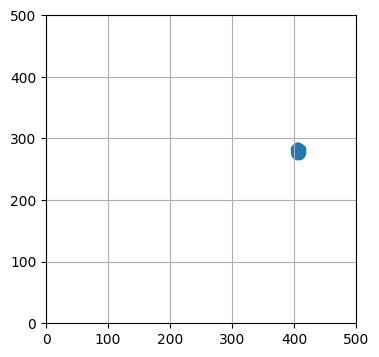

406.2396207151512 +/- 1.3911022259396495
279.71027573134427 +/- 2.0467831664395577


In [34]:

def process_data(array):
    coords = array[1][0]
    rows = coords % 10
    cols = coords // 10
    vals = array[1][1]
    # centroid calculation
    x_rec = find_peak(cols,vals)
    y_rec = find_peak(rows,vals)
    x_mm = 31.25+x_rec * spacing
    y_mm = 31.25+y_rec * spacing
    return (x_mm,y_mm)

xrecs = []
yrecs = []
for i in range(len(big_array)):
    for j in range(len(big_array[i])):
        # print(big_array[i][j][1][0])
        x, y = process_data(big_array[i][j])
        xrecs.append(x)
        yrecs.append(y)
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
ax.scatter(xrecs,yrecs)
ax.set_xlim(0,500)
ax.set_ylim(0,500)
ax.grid()

plt.show()

xr = np.array(xrecs)
yr = np.array(yrecs)

print(f'{np.mean(xr)} +/- {np.std(xr)}')
print(f'{np.mean(yr)} +/- {np.std(yr)}')
